In [45]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import random
from torchvision import datasets
from torch.utils.data import DataLoader

In [46]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Detected device: {device.upper()}")

MODELS = [
    "RN50",
    "RN101",
    "RN50x4",
    "RN50x16",
    "RN50x64",
    "ViT-B/32",
    "ViT-B/16",
    "ViT-L/14",
    "ViT-L/14@336px"
]

model, preprocess = clip.load(MODELS[5], device=device)

Detected device: CUDA


## MNIST zero-shot with CLIP
This uses MNIST digits as input and CLIP text prompts as labels.

In [ ]:
labels = [f"{i}" for i in range(10)]

In [49]:
mnist_root = Path.cwd().parent / "images"

mnist = datasets.MNIST(root=mnist_root, train=False, download=True)

def pil_collate(batch):
    images, targets = zip(*batch)
    return list(images), torch.tensor(targets)

loader = DataLoader(mnist, batch_size=64, shuffle=False, collate_fn=pil_collate)

text = clip.tokenize(labels).to(device)

correct = 0
total = 0
with torch.no_grad():
    for images, targets in loader:
        # Convert MNIST (1x28x28) to PIL RGB, then CLIP preprocess
        image_inputs = torch.stack([preprocess(img.convert("RGB")) for img in images]).to(device)
        logits_per_image, _ = model(image_inputs, text)
        preds = logits_per_image.argmax(dim=-1).cpu()

        correct += (preds == targets).sum().item()
        total += targets.numel()
        # Limit to a small sample for quick feedback
        if total >= 2048:
            break

print(f"Zero-shot CLIP accuracy on {total} MNIST samples: {correct / total:.3f}")

Zero-shot CLIP accuracy on 2048 MNIST samples: 0.341


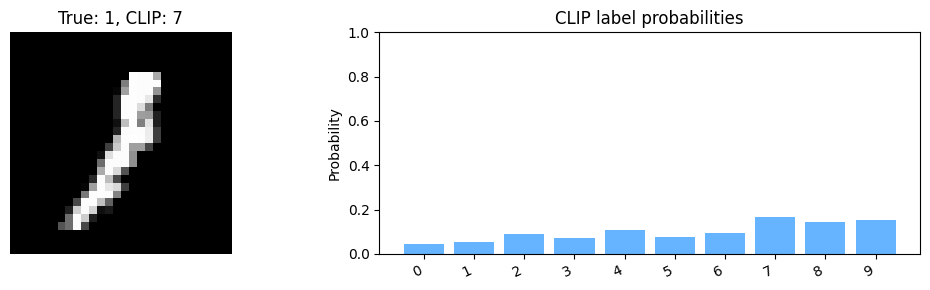

In [52]:
# Plot one MNIST example with CLIP prediction + all label probabilities
mnist_size = len(mnist)
idx = random.randrange(0, mnist_size)
sample_img, sample_target = mnist[idx]
image_input = preprocess(sample_img.convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.imshow(sample_img, cmap="gray")
ax1.set_title(f"True: {sample_target}, CLIP: {pred_idx}")
ax1.axis("off")

ax2.bar(range(len(labels)), probs, color="#66b3ff")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=25, ha="right")
ax2.set_ylabel("Probability")
ax2.set_ylim(0, 1)
ax2.set_title("CLIP label probabilities")

plt.tight_layout()
plt.show()

In [80]:
numbers_written = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]

labels_written = labels = [f"number {numbers_written[i]}" for i in range(10)]

mnist_root = Path.cwd().parent / "images"

mnist = datasets.MNIST(root=mnist_root, train=False, download=True)

def pil_collate(batch):
    images, targets = zip(*batch)
    return list(images), torch.tensor(targets)

loader = DataLoader(mnist, batch_size=64, shuffle=False, collate_fn=pil_collate)

text = clip.tokenize(labels_written).to(device)

correct = 0
total = 0
with torch.no_grad():
    for images, targets in loader:
        # Convert MNIST (1x28x28) to PIL RGB, then CLIP preprocess
        image_inputs = torch.stack([preprocess(img.convert("RGB")) for img in images]).to(device)
        logits_per_image, _ = model(image_inputs, text)
        preds = logits_per_image.argmax(dim=-1).cpu()

        correct += (preds == targets).sum().item()
        total += targets.numel()
        # Limit to a small sample for quick feedback
        if total >= 2048:
            break

print(f"Zero-shot CLIP accuracy on {total} MNIST samples: {correct / total:.3f}")

Zero-shot CLIP accuracy on 2048 MNIST samples: 0.148


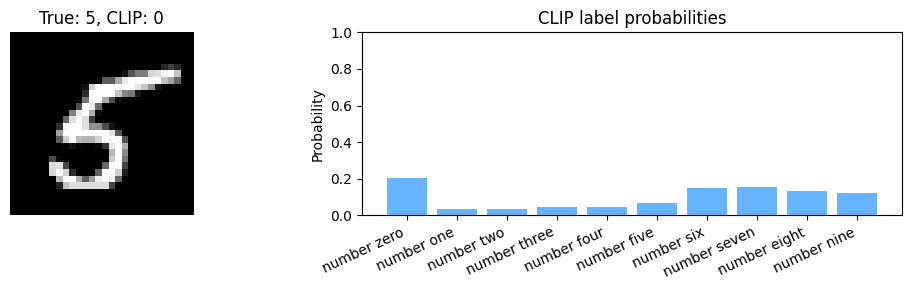

In [82]:
# Plot one MNIST example with CLIP prediction + all label probabilities
mnist_size = len(mnist)
idx = random.randrange(0, mnist_size)
sample_img, sample_target = mnist[idx]
image_input = preprocess(sample_img.convert("RGB")).unsqueeze(0).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.imshow(sample_img, cmap="gray")
ax1.set_title(f"True: {sample_target}, CLIP: {pred_idx}")
ax1.axis("off")

ax2.bar(range(len(labels_written)), probs, color="#66b3ff")
ax2.set_xticks(range(len(labels_written)))
ax2.set_xticklabels(labels_written, rotation=25, ha="right")
ax2.set_ylabel("Probability")
ax2.set_ylim(0, 1)
ax2.set_title("CLIP label probabilities")

plt.tight_layout()
plt.show()